In [168]:
import numpy as np
import pandas as pd
from math import exp
from matplotlib import pyplot, animation
import matplotlib.pyplot as plt
from numpy import sqrt

In [169]:
def u_0(x):
    if x < 2 :
        return 0.4
    else :
        return 0.1

In [170]:
def F(u):
    return (u**2)/2

In [171]:
def U_ex(x, t):
    return u_0(x-(t/4))

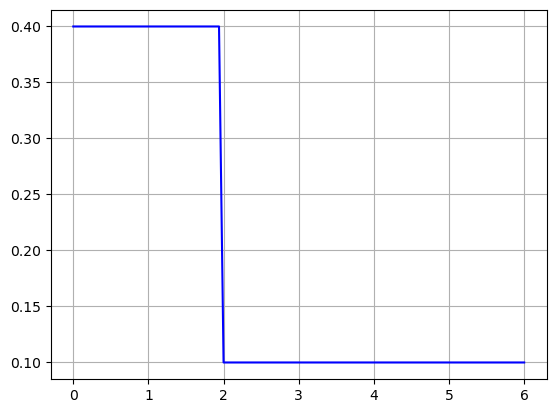

In [172]:
a = 0
b = 6
N = 100
dx = (b-a)/(N-1)
x = np.linspace(a,b,N)
Un = np.zeros(N)
for i in range(N):
    Un[i] = u_0(x[i])
# Tracé de la condition initiale
plt.plot(x,Un,'-b')
plt.grid()

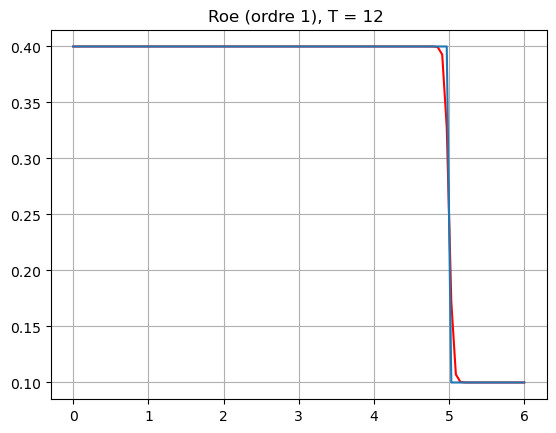

In [173]:
cfl = 0.8
temps = 0
T_final = 12
Unp1 = np.zeros(N)

while(temps < T_final):
    dt = (cfl*dx)/max(abs(Un))
    lam = dt/dx
    for i in range(1,N-1):
        Umoyenne = (Un[i-1]+Un[i])/2
        if Umoyenne >0:
            Fg =  F(Un[i-1])
        else :
            Fg =  F(Un[i])
        Umoyen= (Un[i+1]+Un[i])/2
        if Umoyen >0:
            Fd =  F(Un[i])
        else :
            Fd =  F(Un[i+1])
        Unp1[i] = Un[i] - lam*(Fd-Fg)
    Unp1[0]= Unp1[1]
    Unp1[N-1]= Unp1[N-2]
    Un = Unp1.copy()
    temps = temps + dt
Uex = [U_ex(i,temps) for i in x]
plt.plot(x,Un,'r')
plt.plot(x,Uex,'-')
plt.title('Roe (ordre 1), T = 12 ')
plt.grid()

In [162]:
norm_err = np.linalg.norm(Uex-Un)*np.sqrt(dx)
print(norm_err)
temps

0.02523710957252177


6.060606060606058